# Label Signal Boost Recipes

Use this notebook to rebuild stronger labels from the same candlestick images, then train on the new metadata.


In [1]:
!pip install -q yfinance transformers

In [2]:
import sys
sys.path.insert(1, '/kaggle/input/datasets/romromkankane/signal-boost-final')
import dataset_signal_boost

In [3]:
import sys
sys.path.insert(1, '/kaggle/input/datasets/romromkankane/signal-boost-final')
import kaggle_resnet_vit_boost

In [4]:
from dataset_signal_boost import *
from kaggle_resnet_vit_boost import *

## Build Stronger Binary Labels

Start here. This drops ambiguous samples and usually gives a much cleaner learning target than the original ternary setup.


In [5]:
signal_cfg = SignalConfig(
    data_root='/kaggle/input/datasets/romromkankane/stock-dataset/stock_dataset',
    output_csv='/kaggle/working/metadata_binary_1pct.csv',
    label_mode='binary_fixed',
    threshold=0.01,
    lookahead_days=1,
    purge_gap=19,
)
csv_path, summary_path = save_signal_metadata(signal_cfg)
print(csv_path)
print(summary_path)
pd.read_csv(csv_path)['label'].value_counts()

/kaggle/working/metadata_binary_1pct.csv
/kaggle/working/metadata_binary_1pct.summary.json


label
down    5701
up      4316
Name: count, dtype: int64

## Train ResNet50 On New Metadata

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 186MB/s] 


[01/14] train_acc=0.6453 val_acc=0.5283 train_f1=0.6450 val_f1=0.5224 lr=4.94e-05
[02/14] train_acc=0.8581 val_acc=0.5339 train_f1=0.8581 val_f1=0.5334 lr=4.76e-05
[03/14] train_acc=0.9311 val_acc=0.5290 train_f1=0.9311 val_f1=0.5116 lr=4.47e-05
[04/14] train_acc=0.9655 val_acc=0.5311 train_f1=0.9655 val_f1=0.4833 lr=4.08e-05
[05/14] train_acc=0.9769 val_acc=0.5654 train_f1=0.9769 val_f1=0.5349 lr=3.61e-05
[06/14] train_acc=0.9864 val_acc=0.5640 train_f1=0.9864 val_f1=0.5428 lr=3.10e-05
[07/14] train_acc=0.9924 val_acc=0.5549 train_f1=0.9924 val_f1=0.5467 lr=2.55e-05
[08/14] train_acc=0.9943 val_acc=0.5640 train_f1=0.9943 val_f1=0.5392 lr=2.00e-05
[09/14] train_acc=0.9959 val_acc=0.5710 train_f1=0.9959 val_f1=0.5490 lr=1.49e-05
[10/14] train_acc=0.9980 val_acc=0.5514 train_f1=0.9980 val_f1=0.5173 lr=1.02e-05
[11/14] train_acc=0.9992 val_acc=0.5640 train_f1=0.9992 val_f1=0.5309 lr=6.35e-06
[12/14] train_acc=0.9993 val_acc=0.5633 train_f1=0.9993 val_f1=0.5392 lr=3.43e-06
[13/14] train_ac

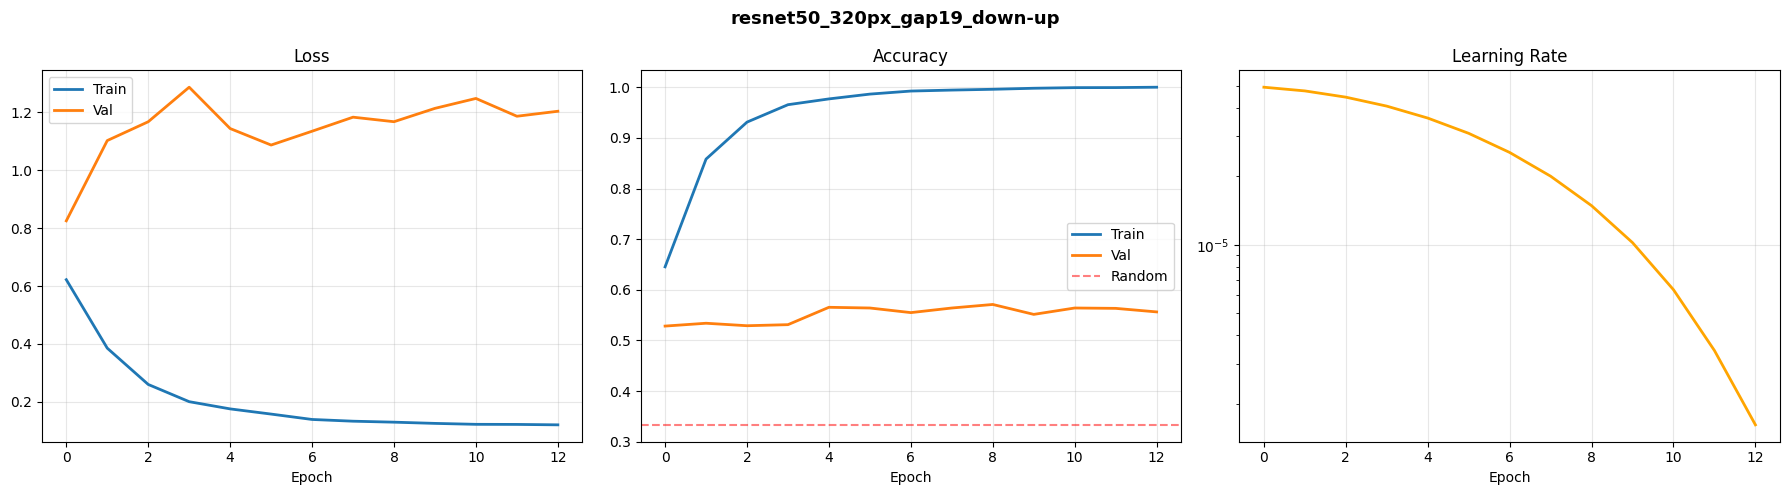

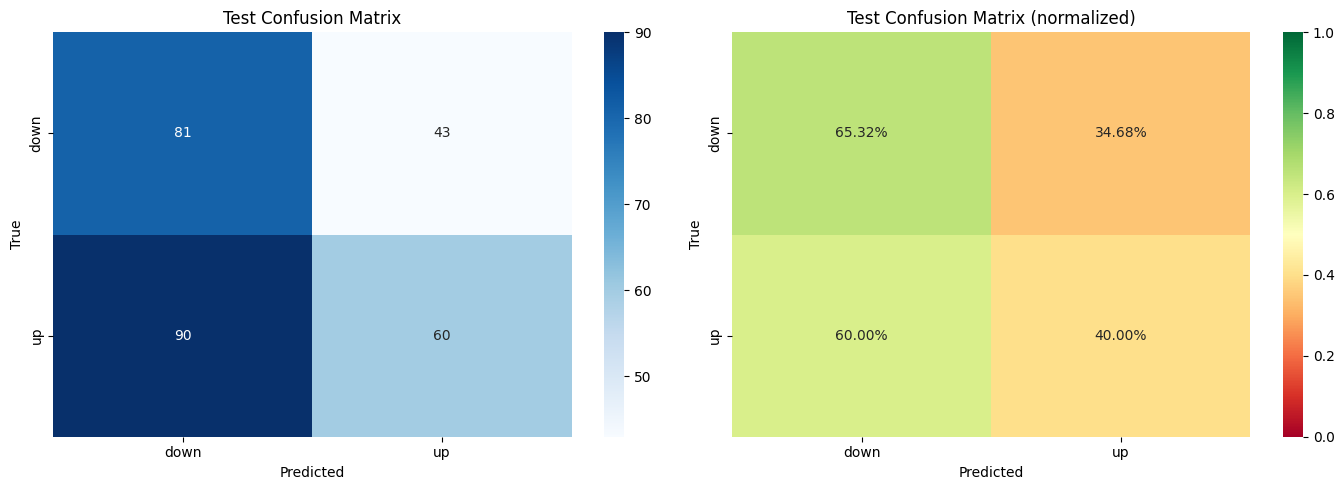

,precision,recall,f1-score,support
down,0.473684,0.653226,0.549153,124.000000
up,0.582524,0.400000,0.474308,150.000000
accuracy,0.514599,0.514599,0.514599,0.514599
macro avg,0.528104,0.526613,0.511730,274.000000
weighted avg,0.533268,0.514599,0.508179,274.000000


In [6]:
train_cfg = TrainConfig(
    data_root='/kaggle/input/stock-dataset/stock_dataset',
    metadata_csv=str(csv_path),
    model_family='resnet50',
    class_names=('down', 'up'),
    image_size=320,
    batch_size=32,
    epochs=14,
    patience=4,
    purge_gap=19,
)
report = train_model(train_cfg)
plot_history(report)
plot_confusion(report)
pd.DataFrame(report['test']['classification_report']).T

## Train DeiT On The Same Metadata

Use this after the ResNet run. If GPU memory is tight, lower `batch_size` to `8`.


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


pytorch_model.bin:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: facebook/deit-base-patch16-224
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([2])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([2, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

[01/12] train_acc=0.5386 val_acc=0.5430 train_f1=0.5379 val_f1=0.4436 lr=2.95e-05
[02/12] train_acc=0.6941 val_acc=0.5360 train_f1=0.6930 val_f1=0.4987 lr=2.81e-05
[03/12] train_acc=0.8311 val_acc=0.5185 train_f1=0.8311 val_f1=0.4946 lr=2.58e-05
[04/12] train_acc=0.9236 val_acc=0.5213 train_f1=0.9236 val_f1=0.5199 lr=2.28e-05
[05/12] train_acc=0.9591 val_acc=0.5255 train_f1=0.9591 val_f1=0.4958 lr=1.93e-05
Early stopping at epoch 5
Saved summary to /kaggle/working/candlestick_runs/deit_224px_gap19_down-up_summary.json


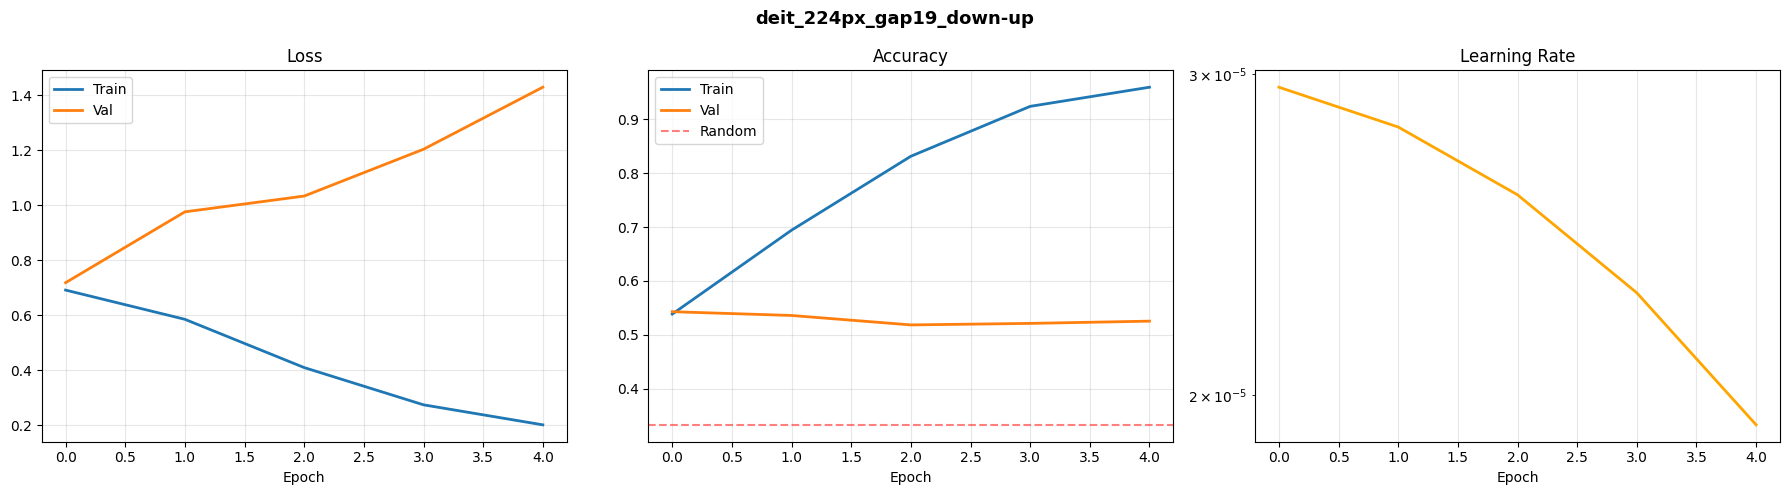

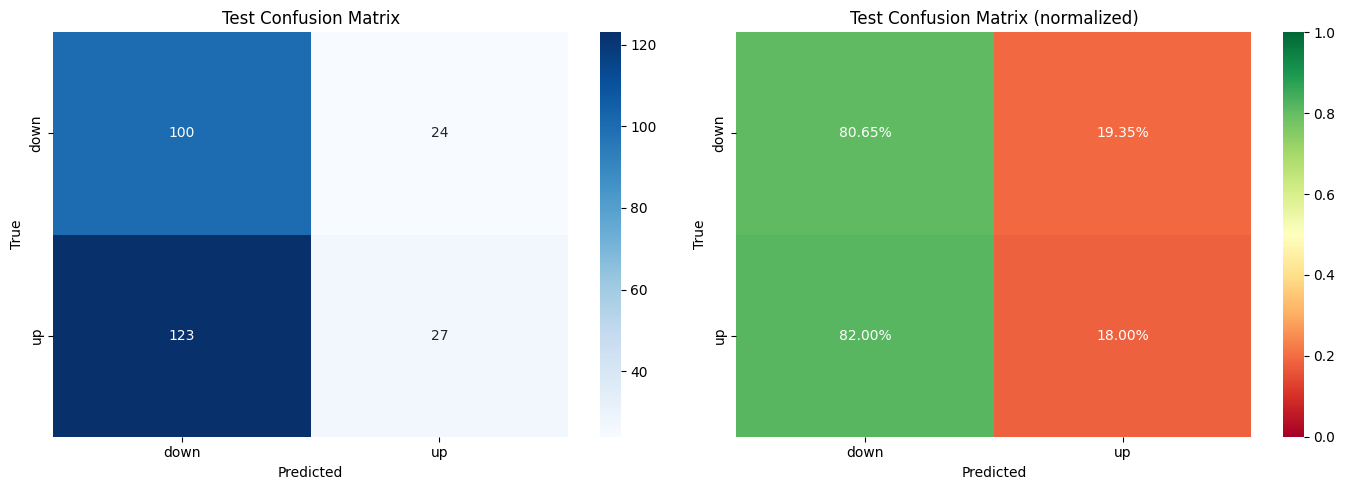

,precision,recall,f1-score,support
down,0.448430,0.806452,0.576369,124.000000
up,0.529412,0.180000,0.268657,150.000000
accuracy,0.463504,0.463504,0.463504,0.463504
macro avg,0.488921,0.493226,0.422513,274.000000
weighted avg,0.492763,0.463504,0.407913,274.000000


In [7]:
vit_cfg = TrainConfig(
    data_root='/kaggle/input/stock-dataset/stock_dataset',
    metadata_csv=str(csv_path),
    model_family='deit',
    vit_checkpoint='facebook/deit-base-patch16-224',
    class_names=('down', 'up'),
    image_size=224,
    batch_size=16,
    epochs=12,
    patience=4,
    lr_backbone=3e-5,
    lr_head=2e-4,
    purge_gap=19,
)
vit_report = train_model(vit_cfg)
plot_history(vit_report)
plot_confusion(vit_report)
pd.DataFrame(vit_report['test']['classification_report']).T

## Alternative Recipe: Quantile Labels

If `binary_fixed` still underperforms, try balanced top/bottom quantile labels.


In [8]:
quant_cfg = SignalConfig(
    data_root='/kaggle/input/datasets/romromkankane/stock-dataset/stock_dataset',
    output_csv='/kaggle/working/metadata_binary_quantile.csv',
    label_mode='binary_quantile',
    quantile=0.35,
    lookahead_days=1,
    purge_gap=19,
)
csv_path_q, summary_path_q = save_signal_metadata(quant_cfg)
print(csv_path_q)
pd.read_csv(csv_path_q)['label'].value_counts()

/kaggle/working/metadata_binary_quantile.csv


label
up      5939
down    5399
Name: count, dtype: int64

## Evaluation & Analysis

This section summarizes Accuracy, Precision, Recall, and F1-score, then shows sample predictions and misclassification patterns on the test set.


,run_name,val_acc,val_f1,test_acc,test_f1
0,resnet50_320px_gap19_down-up,0.571029,0.548973,0.514599,0.511730
1,deit_224px_gap19_down-up,0.543037,0.443642,0.463504,0.422513


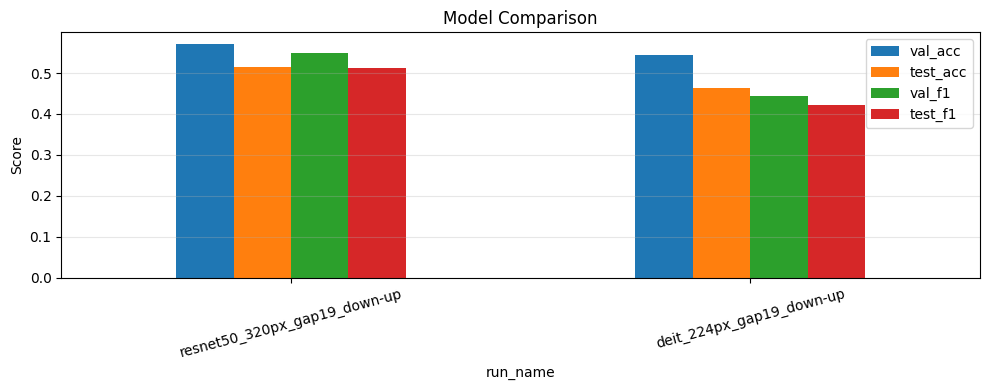

In [9]:
import matplotlib.pyplot as plt

eval_table = compare_reports([report, vit_report])
display(eval_table)

ax = eval_table.set_index('run_name')[['val_acc', 'test_acc', 'val_f1', 'test_f1']].plot(kind='bar', figsize=(10, 4), rot=15)
ax.set_title('Model Comparison')
ax.set_ylabel('Score')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

,stock,timestamp,true_label,pred_label,confidence,correct
0,ASHOKLEY,2026-03-30 13:15:00+05:30,down,down,0.972794,True
1,MPHASIS,2026-04-01 10:15:00+05:30,up,down,0.958933,False
2,PERSISTENT,2026-04-01 14:15:00+05:30,up,down,0.784796,False
3,IRCTC,2026-03-30 14:15:00+05:30,up,down,0.796157,False
4,ULTRACEMCO,2026-04-01 13:15:00+05:30,down,up,0.557595,False
5,SBIN,2026-04-01 10:15:00+05:30,up,down,0.967682,False
6,TATAELXSI,2026-04-01 15:15:00+05:30,up,down,0.928535,False
7,PIIND,2026-04-01 15:15:00+05:30,down,down,0.909188,True
8,TATAELXSI,2026-04-01 11:15:00+05:30,up,up,0.846728,True
9,ROUTE,2026-03-30 15:15:00+05:30,up,up,0.543705,True


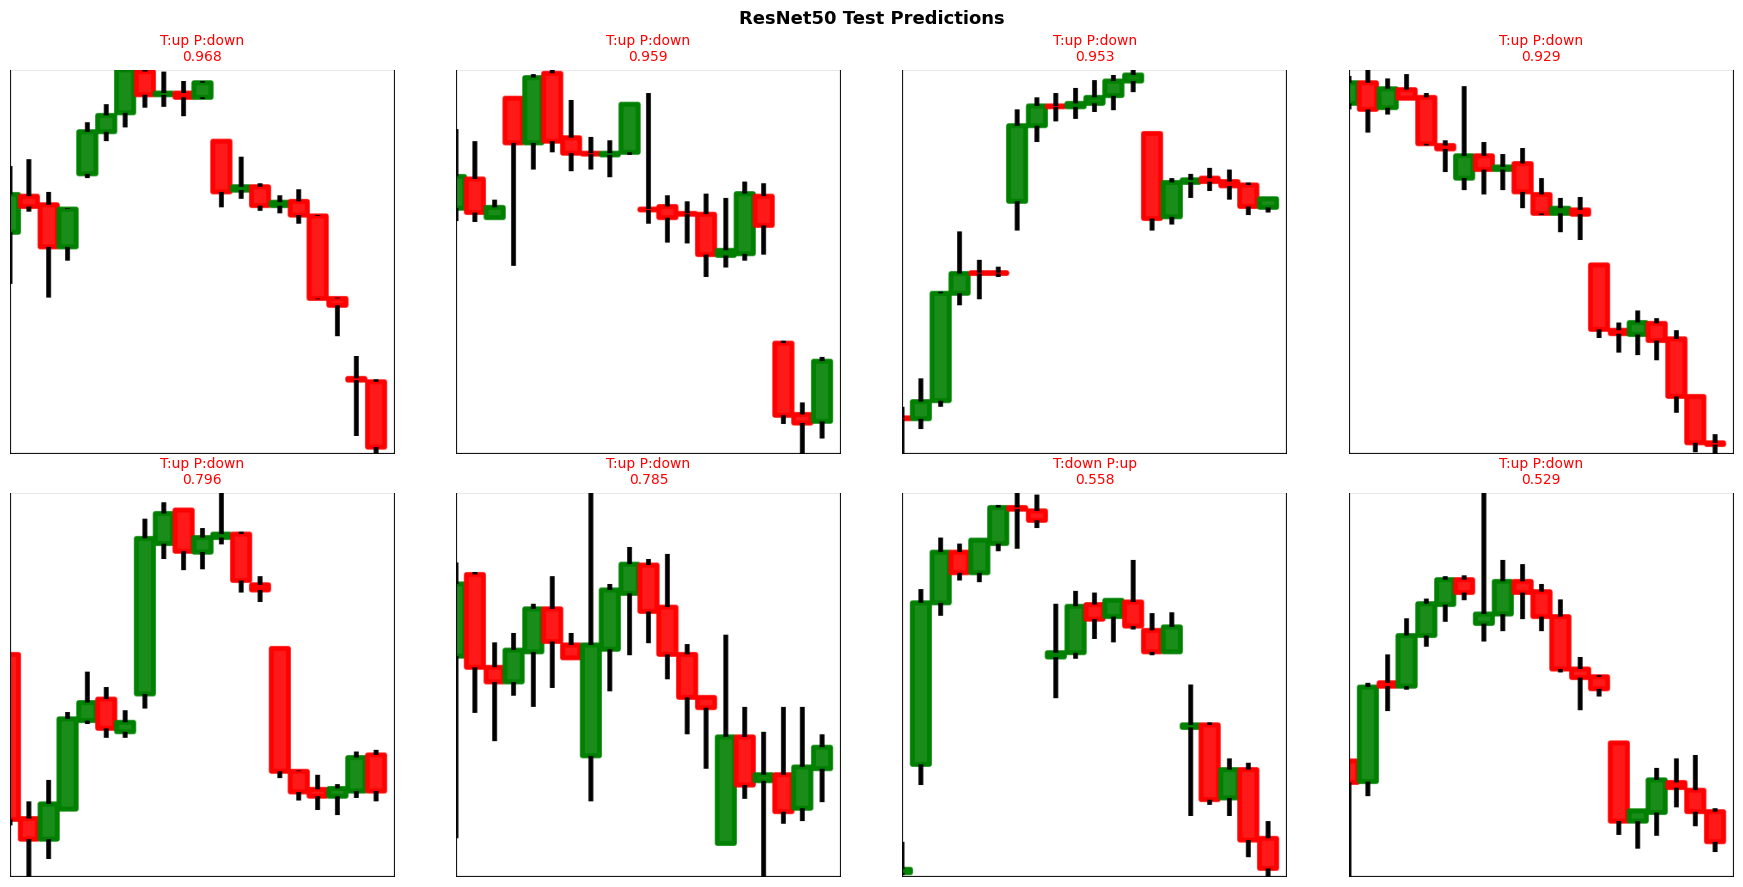

,true_label,pred_label,count,avg_confidence
2,up,down,7,0.845479
0,down,down,2,0.940991
3,up,up,2,0.695217
1,down,up,1,0.557595


In [10]:
resnet_model, resnet_config, resnet_class_names, _ = load_checkpointed_model(report['checkpoint_path'])
resnet_eval_df = build_eval_frame(resnet_config)
resnet_test_df = resnet_eval_df[resnet_eval_df['split'] == 'test'].reset_index(drop=True)
resnet_pred_df = predict_examples(resnet_model, resnet_test_df, resnet_config, resnet_class_names, sample_size=12, seed=42)

display(resnet_pred_df[['stock', 'timestamp', 'true_label', 'pred_label', 'confidence', 'correct']])
plot_prediction_grid(
    resnet_pred_df.sort_values(['correct', 'confidence'], ascending=[True, False]),
    title='ResNet50 Test Predictions',
    n=8,
    cols=4,
)
display(summarize_prediction_errors(resnet_pred_df))

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: facebook/deit-base-patch16-224
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([2])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([2, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.
Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


,stock,timestamp,true_label,pred_label,confidence,correct
0,ASHOKLEY,2026-03-30 13:15:00+05:30,down,down,0.661856,True
1,MPHASIS,2026-04-01 10:15:00+05:30,up,down,0.525079,False
2,PERSISTENT,2026-04-01 14:15:00+05:30,up,down,0.568706,False
3,IRCTC,2026-03-30 14:15:00+05:30,up,down,0.733126,False
4,ULTRACEMCO,2026-04-01 13:15:00+05:30,down,down,0.582172,True
5,SBIN,2026-04-01 10:15:00+05:30,up,up,0.507901,True
6,TATAELXSI,2026-04-01 15:15:00+05:30,up,down,0.567680,False
7,PIIND,2026-04-01 15:15:00+05:30,down,down,0.749252,True
8,TATAELXSI,2026-04-01 11:15:00+05:30,up,up,0.507569,True
9,ROUTE,2026-03-30 15:15:00+05:30,up,up,0.545173,True


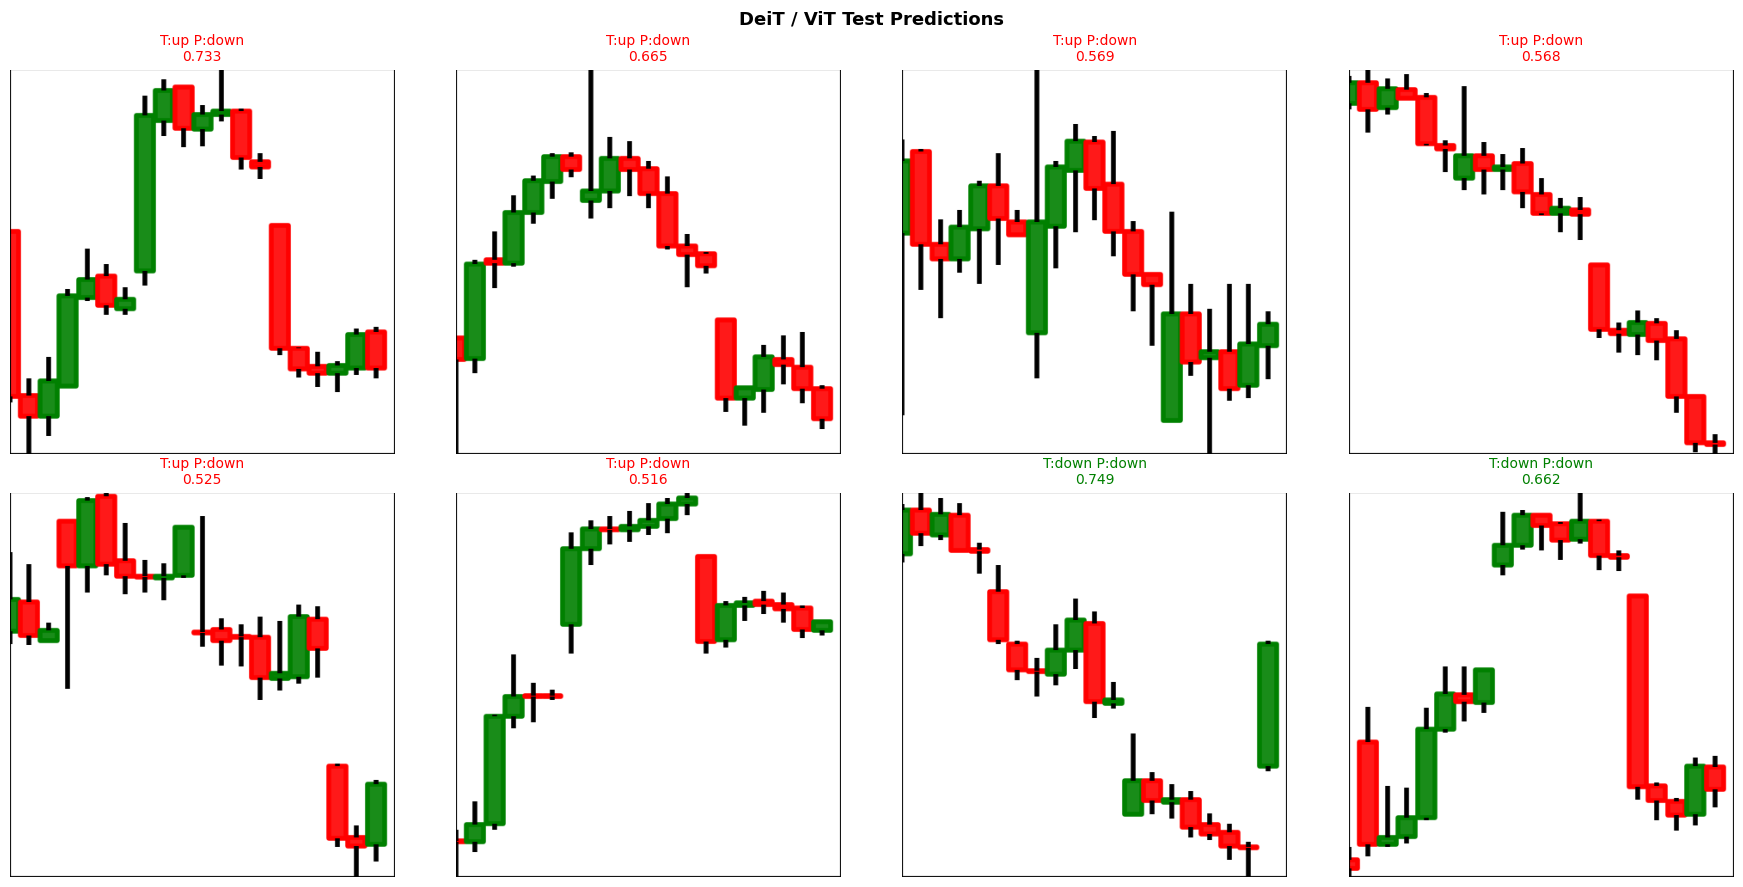

,true_label,pred_label,count,avg_confidence
1,up,down,6,0.595907
0,down,down,3,0.664426
2,up,up,3,0.520214


In [11]:
vit_model, vit_config, vit_class_names, _ = load_checkpointed_model(vit_report['checkpoint_path'])
vit_eval_df = build_eval_frame(vit_config)
vit_test_df = vit_eval_df[vit_eval_df['split'] == 'test'].reset_index(drop=True)
vit_pred_df = predict_examples(vit_model, vit_test_df, vit_config, vit_class_names, sample_size=12, seed=42)

display(vit_pred_df[['stock', 'timestamp', 'true_label', 'pred_label', 'confidence', 'correct']])
plot_prediction_grid(
    vit_pred_df.sort_values(['correct', 'confidence'], ascending=[True, False]),
    title='DeiT / ViT Test Predictions',
    n=8,
    cols=4,
)
display(summarize_prediction_errors(vit_pred_df))

### Pattern Analysis

- The most useful predictions are the high-confidence correct cases, because they show which candlestick formations the model learned consistently.
- The error tables help identify where the model confuses similar movement regimes, which usually happens around small trend changes and low-signal candles.
- Use these plots together with the XAI section to check whether the model is focusing on candle bodies, wicks, and recent trend structure instead of background pixels.


## Explainability (XAI)

This section visualizes which regions of the candlestick chart influenced the trained models. ResNet50 is explained with Grad-CAM, while DeiT/ViT is explained with last-layer attention maps.


In [12]:
from pathlib import Path
import pandas as pd

xai_dir = Path('/kaggle/working/xai_outputs')
xai_dir.mkdir(parents=True, exist_ok=True)
print(xai_dir)

/kaggle/working/xai_outputs


In [13]:
resnet_model, resnet_config, resnet_class_names, resnet_checkpoint = load_checkpointed_model(report['checkpoint_path'])
resnet_eval_df = build_eval_frame(resnet_config)
resnet_test_df = resnet_eval_df[resnet_eval_df['split'] == 'test'].reset_index(drop=True)
resnet_examples = select_examples(resnet_test_df, resnet_class_names, per_class=1, seed=42)
print(report['checkpoint_path'])
display(resnet_examples[['stock', 'timestamp', 'label', 'image_path']])

/kaggle/working/candlestick_runs/resnet50_320px_gap19_down-up.pt


,stock,timestamp,label,image_path
0,APLAPOLLO,2026-04-01 10:15:00+05:30,down,/content/drive/MyDrive/stock_dataset/raw_image...
1,LAURUSLABS,2026-03-30 14:15:00+05:30,up,/content/drive/MyDrive/stock_dataset/raw_image...


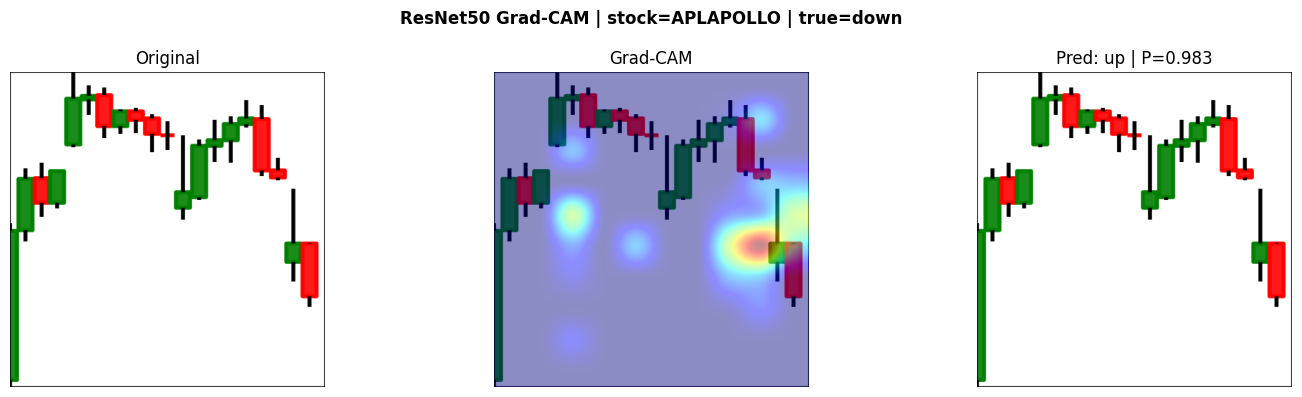

true=down pred=up probs=[0.01696507 0.98303497]


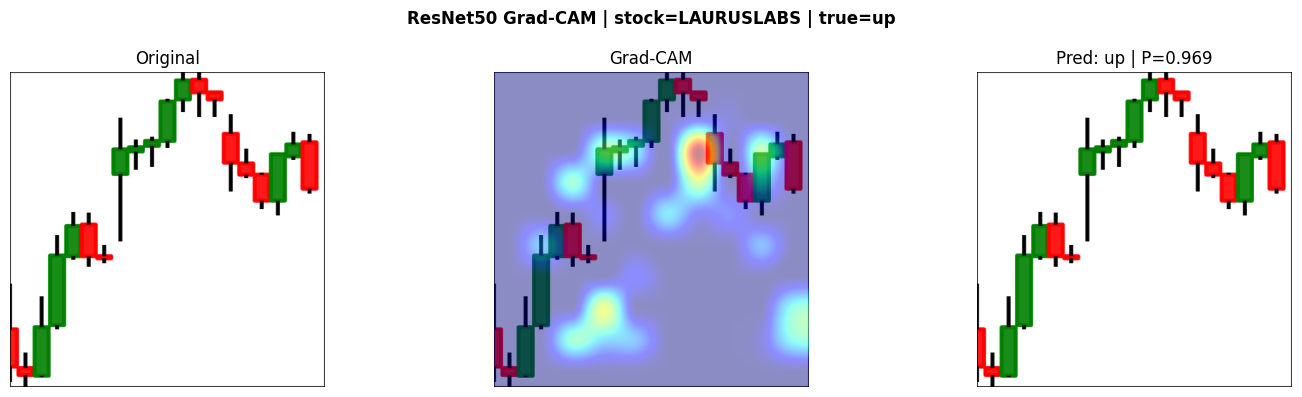

true=up pred=up probs=[0.03065128 0.9693487 ]


In [14]:
for _, row in resnet_examples.iterrows():
    result = plot_xai_triplet(
        row['resolved_path'],
        resnet_model,
        resnet_config,
        resnet_class_names,
        title=f"ResNet50 Grad-CAM | stock={row['stock']} | true={row['label']}",
        method='gradcam',
    )
    print(f"true={row['label']} pred={resnet_class_names[result['pred_idx']]} probs={result['probs']}")

In [15]:
vit_model, vit_config, vit_class_names, vit_checkpoint = load_checkpointed_model(vit_report['checkpoint_path'])
vit_eval_df = build_eval_frame(vit_config)
vit_test_df = vit_eval_df[vit_eval_df['split'] == 'test'].reset_index(drop=True)
vit_examples = select_examples(vit_test_df, vit_class_names, per_class=1, seed=42)
print(vit_report['checkpoint_path'])
display(vit_examples[['stock', 'timestamp', 'label', 'image_path']])

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: facebook/deit-base-patch16-224
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([2])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([2, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


/kaggle/working/candlestick_runs/deit_224px_gap19_down-up.pt


,stock,timestamp,label,image_path
0,APLAPOLLO,2026-04-01 10:15:00+05:30,down,/content/drive/MyDrive/stock_dataset/raw_image...
1,LAURUSLABS,2026-03-30 14:15:00+05:30,up,/content/drive/MyDrive/stock_dataset/raw_image...


In [16]:
for _, row in vit_examples.iterrows():
    result = plot_xai_triplet(
        row['resolved_path'],
        vit_model,
        vit_config,
        vit_class_names,
        title=f"DeiT Attention | stock={row['stock']} | true={row['label']}",
        method='attention',
    )
    print(f"true={row['label']} pred={vit_class_names[result['pred_idx']]} probs={result['probs']}")

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


RuntimeError: DeiT attention tensors are not available from the model output.

### How to read the XAI plots

- For Grad-CAM, the brighter regions indicate where ResNet focused most strongly when making the prediction.
- For attention maps, the highlighted patches show which chart regions the DeiT model attended to most strongly.
- In both cases, the goal is to verify whether the model is focusing on candle bodies, wicks, and recent trend structure rather than background pixels.


## Comparative Study

This project does not try to hard-code classic candlestick rules. Instead, the trained model learns a softer version of those ideas from data. That makes it possible to compare the learned behavior against well-known patterns such as Doji, Hammer, and Engulfing.


In [17]:
comparative_study = pd.DataFrame([
    {
        'Pattern': 'Doji',
        'Traditional interpretation': 'Indecision or balance between buyers and sellers',
        'Similarity to model': 'Both can react to weak momentum and uncertain reversal points',
        'Difference from model': 'The model also uses the surrounding trend and neighboring candles, not just body symmetry',
    },
    {
        'Pattern': 'Hammer',
        'Traditional interpretation': 'Potential bullish reversal after a decline',
        'Similarity to model': 'Both may pay attention to a long lower wick and price rejection',
        'Difference from model': 'The model can reject a Hammer if the broader sequence still looks weak',
    },
    {
        'Pattern': 'Engulfing',
        'Traditional interpretation': 'Stronger reversal or momentum shift',
        'Similarity to model': 'Both capture strong directional candles and body dominance',
        'Difference from model': 'The model learns from many examples and produces graded confidence rather than a strict rule',
    },
])
display(comparative_study)

print('Takeaway: the CNN/ViT model behaves like a data-driven extension of classical candlestick analysis.')
print('It can recover familiar ideas such as reversal and continuation, but it also incorporates broader context.')


,Pattern,Traditional interpretation,Similarity to model,Difference from model
0,Doji,Indecision or balance between buyers and sellers,Both can react to weak momentum and uncertain ...,The model also uses the surrounding trend and ...
1,Hammer,Potential bullish reversal after a decline,Both may pay attention to a long lower wick an...,The model can reject a Hammer if the broader s...
2,Engulfing,Stronger reversal or momentum shift,Both capture strong directional candles and bo...,The model learns from many examples and produc...


Takeaway: the CNN/ViT model behaves like a data-driven extension of classical candlestick analysis.
It can recover familiar ideas such as reversal and continuation, but it also incorporates broader context.
